# Sensor-Based Chicken Meat Freshness Classification

This project aims to predict the freshness of chicken meat using sensor-based data (Volatile Organic Compounds - VOC).

## Project Pipeline:
- SQL -> initial data cleaning
- Pandas -> advanced data cleaning
- Machine Learning -> classification model

## Dataset Description

This dataset simulates a sensor-based system for monitoring chicken meat freshness using VOC (Volatile Organic Compound) signals.

- The dataset contains 10 sensor features ('Sensor_1' to 'Sensor_10'), representing responses from simulated electronic nose (e-nose) sensors.
- These sensors do not correspond to specific chemical compounds but rather capture patterns associated with meat freshness.
- Additional statistical features ('Mean_Value', 'Variance') summarize sensor behavior.

## Target Variable

The 'Target' column represents a combination of:
- Meat condition: Fresh or Frozen-Thawed
- Shelf-life stage: Day 0, 2, 4, 6, 8

Example:
- 'Fresh_Day0'
- 'FrozenThawed_Day6'

This makes the problem a **multi-class classification task**.

In [1]:
import pandas as pd

# Cargar dataset
df = pd.read_csv("chicken_meat_freshness.csv")

# Ver primeras filas
df.head()

,Category,Shelf_Life_Day,Sensor_1,Sensor_2,Sensor_3,Sensor_4,Sensor_5,Sensor_6,Sensor_7,Sensor_8,Sensor_9,Sensor_10,Mean_Value,Variance,Target
0,Fresh,0,0.604967,0.598617,0.606477,0.615230,0.597658,0.597659,0.615792,0.607674,0.595305,0.605426,0.604481,0.000047,Fresh_Day0
1,Fresh,0,0.595366,0.595343,0.602420,0.580867,0.582751,0.594377,0.589872,0.603142,0.590920,0.585877,0.592093,0.000051,Fresh_Day0
2,Fresh,0,0.614656,0.597742,0.600675,0.585753,0.594556,0.601109,0.588490,0.603757,0.593994,0.597083,0.597782,0.000060,Fresh_Day0
3,Fresh,0,0.593983,0.618523,0.599865,0.589423,0.608225,0.587792,0.602089,0.580403,0.586718,0.601969,0.596899,0.000118,Fresh_Day0
4,Fresh,0,0.607385,0.601714,0.598844,0.596989,0.585215,0.592802,0.595394,0.610571,0.603436,0.582370,0.597472,0.000073,Fresh_Day0


In [2]:
# Informacion general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Category        1000 non-null   object 
 1   Shelf_Life_Day  1000 non-null   int64  
 2   Sensor_1        1000 non-null   float64
 3   Sensor_2        1000 non-null   float64
 4   Sensor_3        1000 non-null   float64
 5   Sensor_4        1000 non-null   float64
 6   Sensor_5        1000 non-null   float64
 7   Sensor_6        1000 non-null   float64
 8   Sensor_7        1000 non-null   float64
 9   Sensor_8        1000 non-null   float64
 10  Sensor_9        1000 non-null   float64
 11  Sensor_10       1000 non-null   float64
 12  Mean_Value      1000 non-null   float64
 13  Variance        1000 non-null   float64
 14  Target          1000 non-null   object 
dtypes: float64(12), int64(1), object(2)
memory usage: 117.3+ KB


In [3]:
# Ver valores nulos
df.isnull().sum()

Category          0
Shelf_Life_Day    0
Sensor_1          0
Sensor_2          0
Sensor_3          0
Sensor_4          0
Sensor_5          0
Sensor_6          0
Sensor_7          0
Sensor_8          0
Sensor_9          0
Sensor_10         0
Mean_Value        0
Variance          0
Target            0
dtype: int64

## Load Data into SQLite Database

In this step, we store the dataset into a SQLite database to perform initial data cleaning using SQL queries.

This approach simulates real-world data workflows where data is often stored and processed in databases before analysis.

In [4]:
import sqlite3
# Crear conexion a base de datos 
conn = sqlite3.connect("chicken_freshness.db")
# Guardar dataframe como tabla SQL
df.to_sql("chicken_data", conn, if_exists="replace", index=False)
print("Database and table created successfully.")

Database and table created successfully.


In [5]:
query = "SELECT * FROM chicken_data LIMIT 5;"
pd.read_sql(query, conn)

,Category,Shelf_Life_Day,Sensor_1,Sensor_2,Sensor_3,Sensor_4,Sensor_5,Sensor_6,Sensor_7,Sensor_8,Sensor_9,Sensor_10,Mean_Value,Variance,Target
0,Fresh,0,0.604967,0.598617,0.606477,0.615230,0.597658,0.597659,0.615792,0.607674,0.595305,0.605426,0.604481,0.000047,Fresh_Day0
1,Fresh,0,0.595366,0.595343,0.602420,0.580867,0.582751,0.594377,0.589872,0.603142,0.590920,0.585877,0.592093,0.000051,Fresh_Day0
2,Fresh,0,0.614656,0.597742,0.600675,0.585753,0.594556,0.601109,0.588490,0.603757,0.593994,0.597083,0.597782,0.000060,Fresh_Day0
3,Fresh,0,0.593983,0.618523,0.599865,0.589423,0.608225,0.587792,0.602089,0.580403,0.586718,0.601969,0.596899,0.000118,Fresh_Day0
4,Fresh,0,0.607385,0.601714,0.598844,0.596989,0.585215,0.592802,0.595394,0.610571,0.603436,0.582370,0.597472,0.000073,Fresh_Day0


## Initial Data Exploration using SQL

In this step, we explore the dataset using SQL queries to understand:
- Class distribution
- Data balance
- Key patterns

In [6]:
query = """
SELECT Target, COUNT(*) as count
FROM chicken_data
GROUP BY Target
ORDER BY count DESC;
"""
pd.read_sql(query, conn)


,Target,count
0,FrozenThawed_Day8,100
1,FrozenThawed_Day6,100
2,FrozenThawed_Day4,100
3,FrozenThawed_Day2,100
4,FrozenThawed_Day0,100
5,Fresh_Day8,100
6,Fresh_Day6,100
7,Fresh_Day4,100
8,Fresh_Day2,100
9,Fresh_Day0,100


In [7]:
query = """
SELECT Category, COUNT(*) as count
FROM chicken_data
GROUP BY Category;
"""
pd.read_sql(query, conn)

,Category,count
0,Fresh,500
1,FrozenThawed,500


In [8]:
query = """
SELECT Target,
        AVG(Sensor_1) as avg_s1,
        AVG(Sensor_2) as avg_s2,
        AVG(Sensor_3) as avg_s3
FROM chicken_data
GROUP BY Target;
"""
pd.read_sql(query, conn)

,Target,avg_s1,avg_s2,avg_s3
0,Fresh_Day0,0.600036,0.600026,0.599515
1,Fresh_Day2,0.560778,0.560753,0.560608
2,Fresh_Day4,0.520432,0.521200,0.519924
3,Fresh_Day6,0.479611,0.479478,0.480005
4,Fresh_Day8,0.439299,0.439551,0.440202
5,FrozenThawed_Day0,0.400169,0.399726,0.399884
6,FrozenThawed_Day2,0.361075,0.359650,0.359632
7,FrozenThawed_Day4,0.322134,0.320229,0.319481
8,FrozenThawed_Day6,0.277826,0.281289,0.279147
9,FrozenThawed_Day8,0.239717,0.241227,0.239349


## Data Cleaning using SQL

Although the dataset is clean, we perform SQL-based selection and transformation to simulate real-world preprocessing workflows.
We will:
- Select relevant columns
- Prepare a clean dataset for further analysis

In [9]:
query = """
SELECT
    Category,
    Shelf_Life_Day,
    Sensor_1,
    Sensor_2,
    Sensor_3,
    Sensor_4,
    Sensor_5,
    Sensor_6,
    Sensor_7,
    Sensor_8,
    Sensor_9,
    Sensor_10,
    Mean_Value,
    Variance,
    Target
FROM chicken_data;
""" 
df_sql_clean = pd.read_sql(query, conn)
df_sql_clean.head()

,Category,Shelf_Life_Day,Sensor_1,Sensor_2,Sensor_3,Sensor_4,Sensor_5,Sensor_6,Sensor_7,Sensor_8,Sensor_9,Sensor_10,Mean_Value,Variance,Target
0,Fresh,0,0.604967,0.598617,0.606477,0.615230,0.597658,0.597659,0.615792,0.607674,0.595305,0.605426,0.604481,0.000047,Fresh_Day0
1,Fresh,0,0.595366,0.595343,0.602420,0.580867,0.582751,0.594377,0.589872,0.603142,0.590920,0.585877,0.592093,0.000051,Fresh_Day0
2,Fresh,0,0.614656,0.597742,0.600675,0.585753,0.594556,0.601109,0.588490,0.603757,0.593994,0.597083,0.597782,0.000060,Fresh_Day0
3,Fresh,0,0.593983,0.618523,0.599865,0.589423,0.608225,0.587792,0.602089,0.580403,0.586718,0.601969,0.596899,0.000118,Fresh_Day0
4,Fresh,0,0.607385,0.601714,0.598844,0.596989,0.585215,0.592802,0.595394,0.610571,0.603436,0.582370,0.597472,0.000073,Fresh_Day0


In [10]:
df_sql_clean.shape

(1000, 15)

## Data Preparation using Pandas

In this step, we prepare the dataset for machine learning:

- Define features (X) and target (y)
- Remove redundant columns
- Ensure only sensor-based data is used for prediction


In [11]:
# Target
y = df_sql_clean["Target"]

# Features
X = df_sql_clean.drop(columns=["Target", "Category", "Shelf_Life_Day"])
X.head()

,Sensor_1,Sensor_2,Sensor_3,Sensor_4,Sensor_5,Sensor_6,Sensor_7,Sensor_8,Sensor_9,Sensor_10,Mean_Value,Variance
0,0.604967,0.598617,0.606477,0.615230,0.597658,0.597659,0.615792,0.607674,0.595305,0.605426,0.604481,0.000047
1,0.595366,0.595343,0.602420,0.580867,0.582751,0.594377,0.589872,0.603142,0.590920,0.585877,0.592093,0.000051
2,0.614656,0.597742,0.600675,0.585753,0.594556,0.601109,0.588490,0.603757,0.593994,0.597083,0.597782,0.000060
3,0.593983,0.618523,0.599865,0.589423,0.608225,0.587792,0.602089,0.580403,0.586718,0.601969,0.596899,0.000118
4,0.607385,0.601714,0.598844,0.596989,0.585215,0.592802,0.595394,0.610571,0.603436,0.582370,0.597472,0.000073


In [12]:
X.shape, y.shape

((1000, 12), (1000,))

In [13]:
y.unique()

array(['Fresh_Day0', 'Fresh_Day2', 'Fresh_Day4', 'Fresh_Day6',
       'Fresh_Day8', 'FrozenThawed_Day0', 'FrozenThawed_Day2',
       'FrozenThawed_Day4', 'FrozenThawed_Day6', 'FrozenThawed_Day8'],
      dtype=object)

## Encoding and Train-Test Split

In this step:
- Convert categorical target labels into numerical values
- Split the dataset into training and testing sets

In [14]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)
# Ver transformacion
list(zip(y[:5], y_encoded[:5]))

[('Fresh_Day0', np.int64(0)),
 ('Fresh_Day0', np.int64(0)),
 ('Fresh_Day0', np.int64(0)),
 ('Fresh_Day0', np.int64(0)),
 ('Fresh_Day0', np.int64(0))]

In [15]:
le.classes_

array(['Fresh_Day0', 'Fresh_Day2', 'Fresh_Day4', 'Fresh_Day6',
       'Fresh_Day8', 'FrozenThawed_Day0', 'FrozenThawed_Day2',
       'FrozenThawed_Day4', 'FrozenThawed_Day6', 'FrozenThawed_Day8'],
      dtype=object)

In [16]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)
X_train.shape, X_test.shape

((800, 12), (200, 12))

## Baseline Model - Logistic Regression

We start with a simple Logistic Regression model to establish a baseline performance.
This helps us understand how well the data can be separated using a linear model.

In [17]:
from sklearn.linear_model import LogisticRegression
# Crear modelo
lr_model = LogisticRegression(max_iter=1000)
# Entrenar
lr_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [18]:
y_pred = lr_model.predict(X_test)

In [19]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.725

In [20]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.50      1.00      0.67        20
           1       0.00      0.00      0.00        20
           2       1.00      0.60      0.75        20
           3       1.00      1.00      1.00        20
           4       1.00      1.00      1.00        20
           5       1.00      1.00      1.00        20
           6       1.00      1.00      1.00        20
           7       1.00      0.65      0.79        20
           8       0.00      0.00      0.00        20
           9       0.50      1.00      0.67        20

    accuracy                           0.72       200
   macro avg       0.70      0.72      0.69       200
weighted avg       0.70      0.72      0.69       200



Logistic Regression struggled to correctly classify certain classes, indicating that the dataset likely contains non-linear relationships between sensor features and freshness levels.

## Random Forest Model

We use a Random Forest classifier to capture non-linear relationships in the data.
This model is expected to outperform Logistic Regression due to its ability to handle complex feature interactions.

In [21]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [22]:
y_pred_rf = rf_model.predict(X_test)

In [23]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
accuracy_rf

1.0

In [24]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       1.00      1.00      1.00        20
           3       1.00      1.00      1.00        20
           4       1.00      1.00      1.00        20
           5       1.00      1.00      1.00        20
           6       1.00      1.00      1.00        20
           7       1.00      1.00      1.00        20
           8       1.00      1.00      1.00        20
           9       1.00      1.00      1.00        20

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



## Model Performance Analysis

The Random Forest model achieved 100% accuracy on the test set.

This indicates that the dataset is highly structured with strong class separability.

This suggests that:
- Sensor values show strong patterns related to freshness levels

However, such perfect performance may also indicate:
- The dataset is relatively simple
- Some features (e.g., mean and variance) may reinforce class separability

This highlights the importance of evaluating models on real-world data, where noise and variability are higher.

## Feature Importance Check

To validate the robustness of the model, we remove derived features ('Mean_Value' and 'Variance') and retrain the model.
This helps determine whether the model relies heavily on these statistical features or if the raw sensor data alone is sufficient.

In [25]:
# Quitar columnas derivadas
X_reduced = df_sql_clean.drop(columns=[
    "Target", "Category", "Shelf_Life_Day",
    "Mean_Value", "Variance"
])
# Split otra vez
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reduced, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)
# Entrenar RF
rf_model_r = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model_r.fit(X_train_r, y_train_r)
# Evaluar
y_pred_r = rf_model_r.predict(X_test_r)
accuracy_score(y_test_r, y_pred_r)

1.0

## Feature Importance Analysis

We analyze feature importance to understand which sensors contribute the most to the model predictions.

In [26]:
import pandas as pd
feature_importances = pd.DataFrame({
    "feature": X.columns,
    "importance": rf_model.feature_importances_
}).sort_values(by="importance", ascending=False)
feature_importances

,feature,importance
10,Mean_Value,0.206857
9,Sensor_10,0.133955
8,Sensor_9,0.116747
1,Sensor_2,0.081631
0,Sensor_1,0.081525
2,Sensor_3,0.079180
7,Sensor_8,0.071197
5,Sensor_6,0.064097
3,Sensor_4,0.061655
6,Sensor_7,0.057181


## Feature Importance Visualization

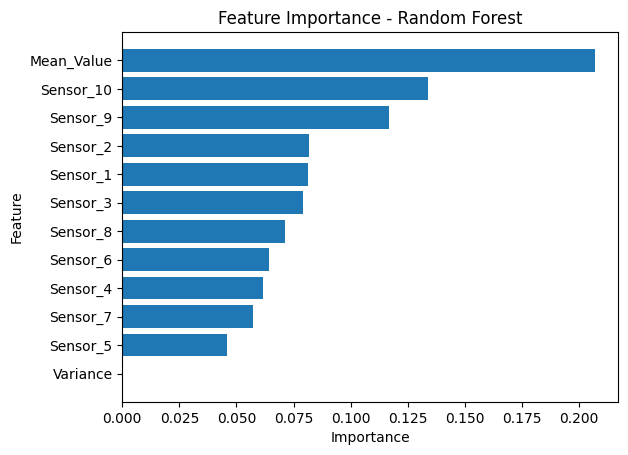

In [27]:
import matplotlib.pyplot as plt
plt.figure()
plt.barh(feature_importances["feature"], feature_importances["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance - Random Forest")
plt.gca().invert_yaxis()
plt.show()

This plot illustrates the importance of each feature in the Random Forest model.

### Interpretation:
- Features with higher importance contribute more to the model's decision-making process.
- `Mean_Value` appears as the most influential feature, indicating that aggregated sensor behavior is highly informative.
- Individual sensors (e.g., Sensor_9, Sensor_10) also play a significant role in distinguishing freshness levels.
- `Variance` shows negligible importance, suggesting it does not add meaningful predictive value.

### Insight:
The model relies primarily on sensor signals and their overall trends to classify meat freshness, while some engineered features contribute little to performance.

## Sensor Behavior Across Freshness Levels

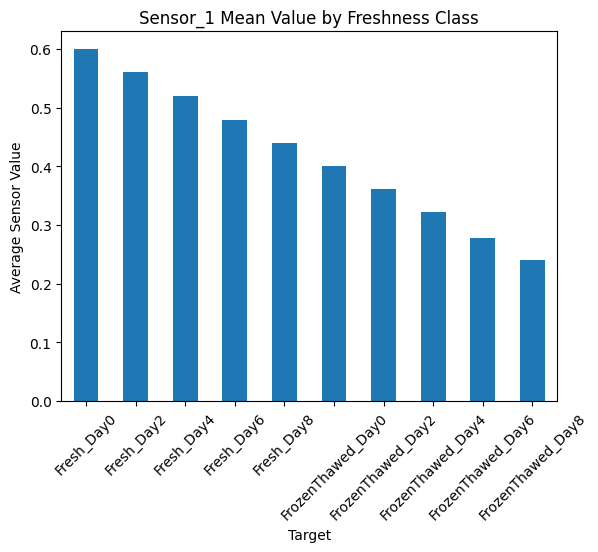

In [28]:
import pandas as pd
sensor_trend = df_sql_clean.groupby("Target")["Sensor_1"].mean()
sensor_trend.plot(kind="bar")
plt.title("Sensor_1 Mean Value by Freshness Class")
plt.xlabel("Target")
plt.ylabel("Average Sensor Value")
plt.xticks(rotation=45)
plt.show()


This plot shows how the average value of a sensor changes across different freshness classes.

### Interpretation:
- There is a clear decreasing trend in sensor values as shelf-life increases.
- Fresh samples tend to have higher sensor readings, while frozen-thawed and older samples show lower values.
- This indicates that sensor responses are strongly correlated with meat freshness.

### Insight:
The consistent pattern observed suggests that the dataset is highly separable, making it easier for machine learning models to distinguish between classes.

## Correlation Matrix

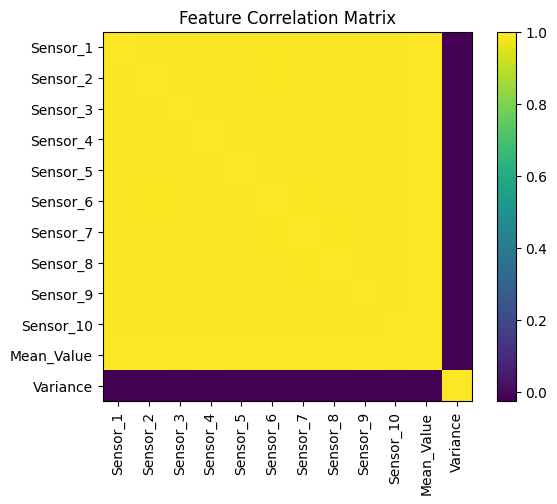

In [29]:
corr = X.corr()
plt.figure()
plt.imshow(corr)
plt.colorbar()
plt.title("Feature Correlation Matrix")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.show()

This heatmap represents the correlation between different sensor features.

### Interpretation:
- High correlation between sensors suggests that some features may capture similar information.
- Strong relationships between variables indicate redundancy in the dataset.
- Low correlation features may provide unique information useful for the model.

### Insight:
Understanding feature correlation helps identify redundant variables and can guide feature selection or dimensionality reduction in more complex scenarios.

## Feature Importance Validation

After removing the derived features ('Mean_Value' and 'Variance'), the Random Forest model still achieved **100% accuracy**.

### Interpretation:

- The raw sensor data alone is sufficient to perfectly classify the freshness levels
- The dataset exhibits very strong patterns and clear separability between classes
- Derived statistical features do not significantly impact model performance

### Conclusion:

In this project, we developed a machine learning pipeline to classify chicken meat freshness using simulated sensor data.

Key takeaways:
- Sensor-based features show strong predictive power for freshness classification
- Logistic Regression struggled due to non-linear relationships
- Random Forest successfully captured complex patterns and achieved perfect classification
- Feature validation confirmed that raw sensor data alone is sufficient

Limitations:
- The dataset is simulated and highly structured
- Real-world data may introduce noise and variability not present here
- Variance showed negligible importance and could be removed without affecting model performance

Future Work:
- Apply models to real-world food quality datasets
- Explore more complex models and feature engineering techniques